In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Dell\Downloads\PYTHON CODE\KAGLE DATA\Bank Customer Churn Prediction.csv")

In [3]:
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# we want to know customer is churn or not.
    # churning: customer left(closed)

<Axes: >

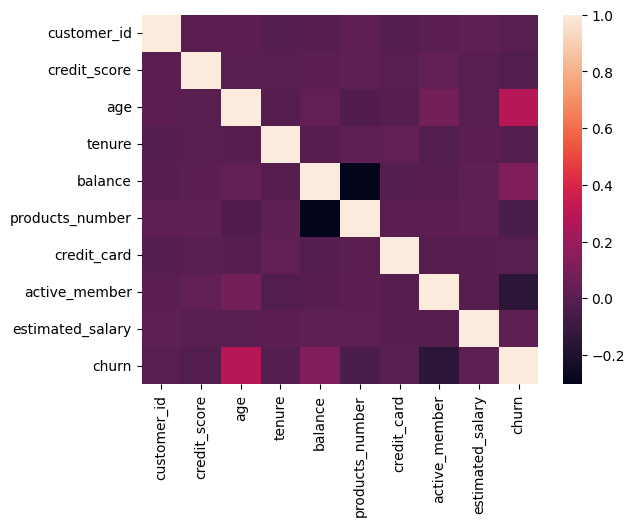

In [7]:
cors=data.corr(numeric_only= True)
sns.heatmap(cors)

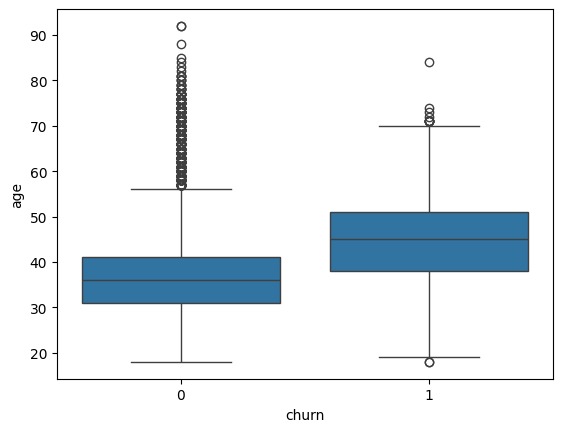

In [8]:
sns.boxplot(x="churn", y="age",data=data)
plt.show()

<Axes: xlabel='churn', ylabel='credit_score'>

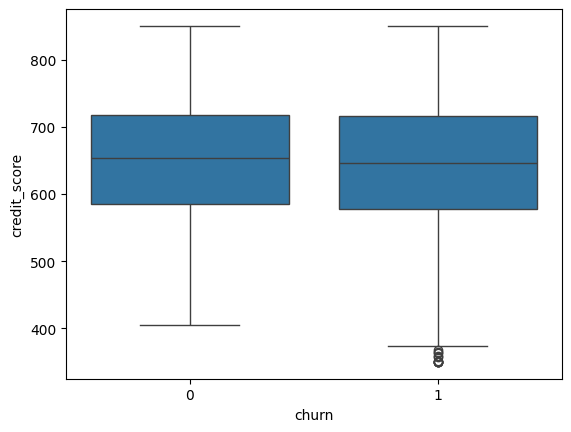

In [9]:
sns.boxplot(x="churn",y="credit_score",data=data)

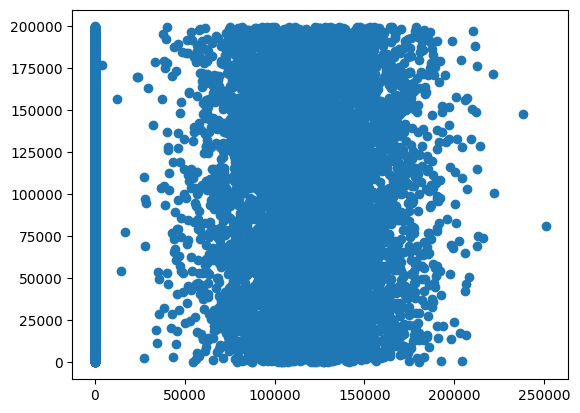

In [10]:
plt.scatter(data['balance'],data['estimated_salary'])

In [11]:
data['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['encoded'] = encoder.fit_transform(data["gender"])
data[['churn','encoded']].head()

,churn,encoded
0,1,0
1,0,0
2,1,0
3,0,0
4,0,0


In [19]:
data['encoded'].value_counts()

encoded
1    5457
0    4543
Name: count, dtype: int64

In [20]:
m_values=5457
f_values=4543
m_churn,f_churn=0,0
for i in range(0,len(data)):
    if(data['churn'][i]==1 and data['encoded'][i]==1):
        m_churn += 1
    elif(data['churn'][i]==1 and data['encoded'][i]==0):
        f_churn += 1

In [21]:
x=[m_churn,f_churn]
print(x)

[898, 1139]


<BarContainer object of 2 artists>

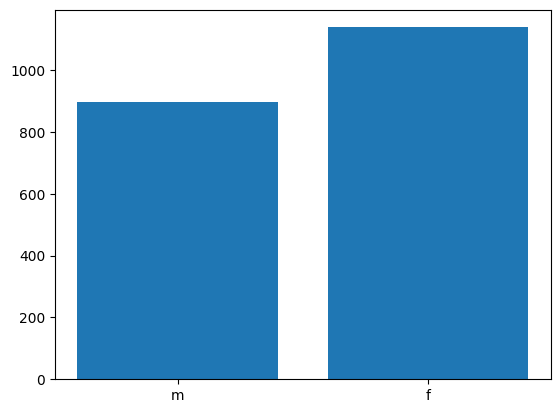

In [22]:
plt.bar(['m','f'],[m_churn,f_churn])

In [24]:
y=data['churn']
x = data[['age','credit_score','encoded','tenure','balance','products_number','credit_card','active_member','estimated_salary']]

In [54]:
from sklearn.model_selection import train_test_split
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaling=StandardScaler()
scaling.fit(x_tr)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [50]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=5000)
model.fit(x_tr,y_tr)
model.score(x_ts,y_ts)

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8095

In [52]:
model.coef_

array([[ 7.33701027e-02, -7.16225781e-04, -5.57590042e-01,
        -1.29985633e-02,  4.83787503e-06, -4.35481385e-02,
        -4.67927674e-02, -1.12821628e+00,  2.82325058e-07]])

In [53]:
from sklearn.pipeline import make_pipeline
test_score=[]
for lam in np.arange(0.01,100,0.1): #lam= lambda= hyperparameter
    pipe=make_pipeline(StandardScaler(),LogisticRegression(C=1/lam))
    pipe.fit(x_tr,y_tr)
    scores=pipe.score(x_ts,y_ts)
    test_score.append(scores)

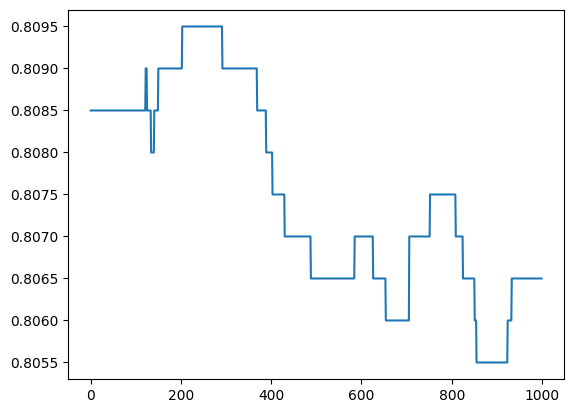

In [56]:
plt.plot(test_score)

In [57]:
np.argmax(test_score)

np.int64(203)

In [58]:
l_best=0.01*203*0.1

In [63]:
x_tr.head()

,age,credit_score,encoded,tenure,balance,products_number,credit_card,active_member,estimated_salary
6384,31,529,0,7,0.00,2,1,1,175697.87
856,49,567,0,5,134956.02,1,1,0,93953.84
4116,31,571,0,3,0.00,2,1,1,194667.92
9527,40,850,0,9,99816.46,1,1,1,163989.66
780,27,639,1,8,0.00,2,1,0,192247.35
